## Notebook to learn to play with tif images

In [1]:
import sys
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")  

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0


In [3]:
settings = {"scene_width": 3,}

In [4]:
import rasterio
import xarray as xr

data_directory = "../data/"

filename = "/landsat_export_1x1/2013_06S_106E.tif"
input_tiff = rasterio.open(data_directory + filename)
print(*zip(input_tiff.indexes, input_tiff.descriptions))

filename = "/landsat_export_1x1/2013_06S_106E_mask.tif"
input_mask = rasterio.open(data_directory + filename)
print(*zip(input_mask.indexes, input_mask.descriptions))

filename = "hfi2013_merisINT.epsg4326.tif"
output_tiff = rasterio.open(data_directory + filename)
print(*zip(output_tiff.indexes, output_tiff.descriptions))

output_mask = output_tiff.read_masks(1) // 255

(1, 'SR_B2') (2, 'SR_B3') (3, 'SR_B4') (4, 'SR_B5') (5, 'SR_B6') (6, 'SR_B7') (7, 'QA_PIXEL') (8, 'NDVI')
(1, 'QA_PIXEL')
(1, None)


In [5]:
print(output_tiff.shape)
print(input_tiff.shape)

(15683, 36390)
(3712, 3712)


In [6]:
print(output_tiff.transform * (0, 0))
print(input_tiff.transform * (0, 0))

print('')
print(output_tiff.crs)
print(input_tiff.crs)
print(input_mask.crs)

print('')
print(output_tiff.transform)
print(input_tiff.transform)

(-179.99999995447257, 89.8976232152096)
(105.99976622164895, -5.999757951105873)

EPSG:4326
EPSG:4326
EPSG:4326

| 0.01, 0.00,-180.00|
| 0.00,-0.01, 89.90|
| 0.00, 0.00, 1.00|
| 0.00, 0.00, 106.00|
| 0.00,-0.00,-6.00|
| 0.00, 0.00, 1.00|


In [7]:
row_len, col_len = 3700, 3700
# row,col = input_tiff.index(106.824278, -6.103286)
row,col = input_tiff.index(106., -6.)

x_topleft, y_topleft = input_tiff.xy(row, col)
x_bottomright, y_bottomright = input_tiff.xy(row+row_len, col+col_len)
print(x_topleft, y_topleft)
print(x_bottomright, y_bottomright)


105.99990096894157 -5.999892698398491
106.99703093431424 -6.99702266377116


3700 3700
(9693, 28910) (9794, 29010)
101 100


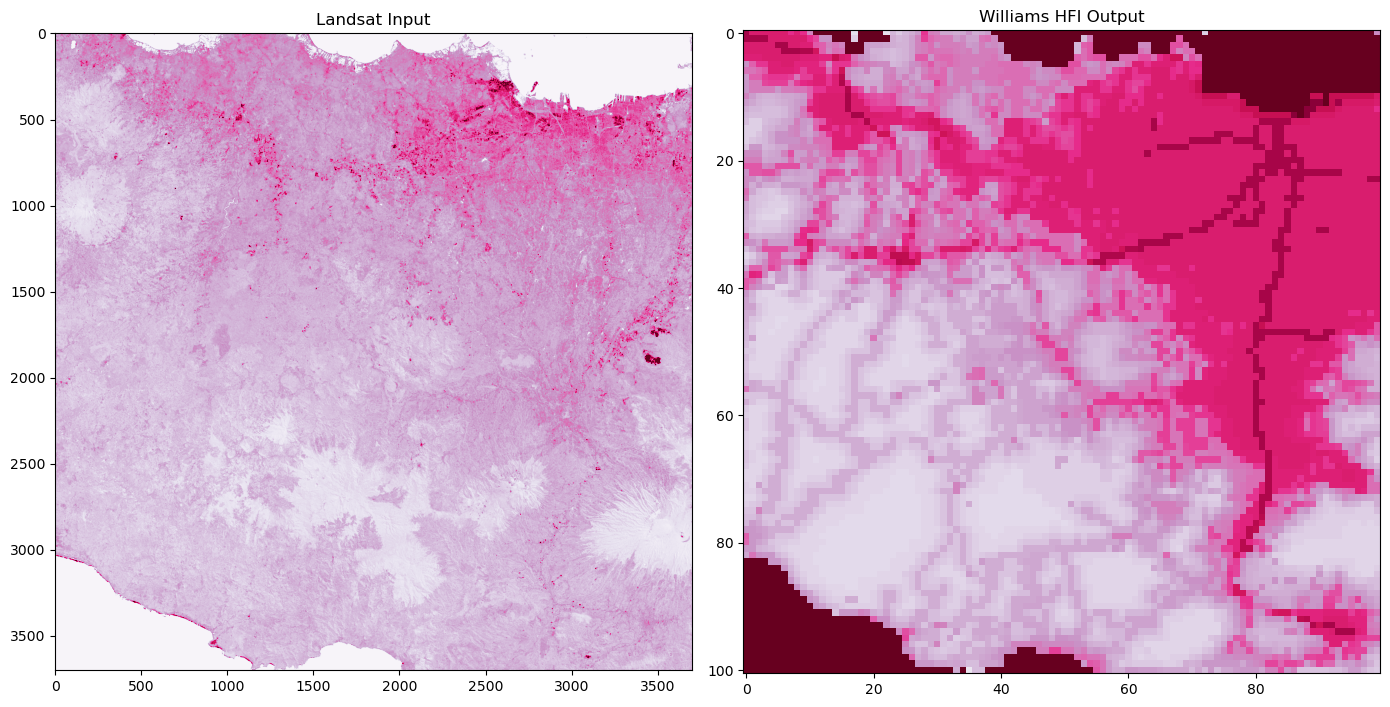

In [8]:
from rasterio.plot import show
import matplotlib as mpl

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))

row, col = input_tiff.index(x_topleft, y_topleft)
row1, col1 = input_tiff.index(x_bottomright, y_bottomright)
print((row1-row), (col1-col))
show(input_mask.read(1)[row:row1, col:col1]*input_tiff.read(2)[row:row1,col:col1], cmap="PuRd", ax=ax1, vmin=0, vmax=50)
ax1.set_title("Landsat Input")


cmap = mpl.colormaps["PuRd"]
row, col = output_tiff.index(x_topleft, y_topleft)
row1, col1 = output_tiff.index(x_bottomright, y_bottomright)
print((row,col), (row1,col1))
print((row1-row), (col1-col))
show(output_tiff.read(1)[row:row1,col:col1], cmap=cmap, vmin=0, vmax=55, ax=ax2)
ax2.set_title("Williams HFI Output")

plt.tight_layout()
plt.show()

106.20175746961911 -6.027277524933325
106.20175241328323 -6.027381146092548


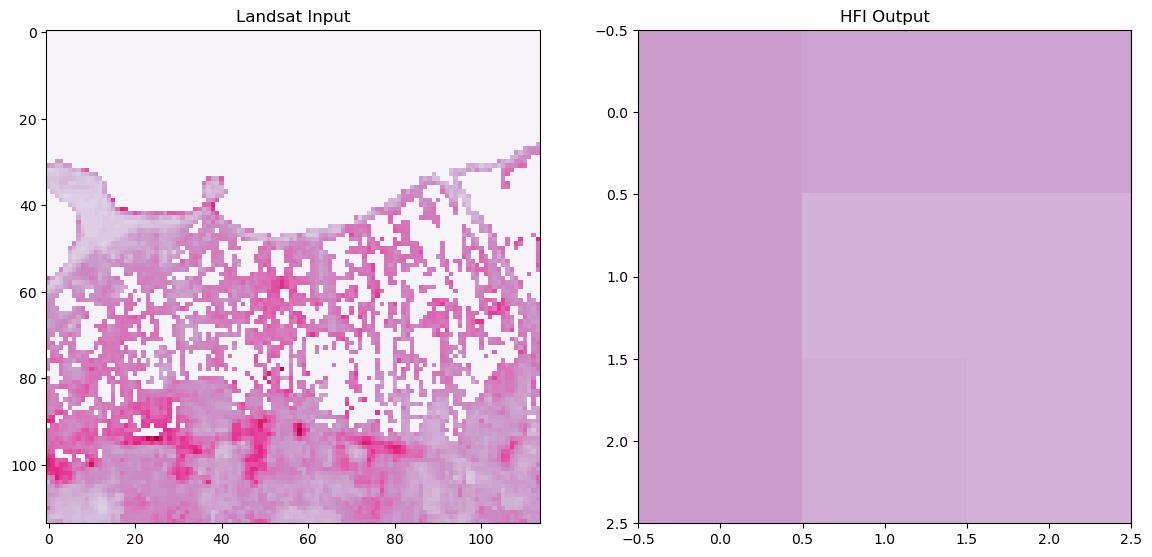

In [9]:
LANDSAT_TO_HFI_RATIO = 38

output_row, output_col = 9693+3, 28910+20
output_x, output_y = output_tiff.xy(output_row, output_col)
print(output_x, output_y)

input_row, input_col = input_tiff.index(output_x, output_y)
input_x, input_y = input_tiff.xy(input_row, input_col)
print(input_x, input_y)

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(14,7))

row0, row1 = input_row - LANDSAT_TO_HFI_RATIO * ((settings["scene_width"]-1)//2+1), input_row + LANDSAT_TO_HFI_RATIO * (settings["scene_width"]-1)//2
col0, col1 = input_col - LANDSAT_TO_HFI_RATIO * (settings["scene_width"]-1)//2, input_col + LANDSAT_TO_HFI_RATIO * ((settings["scene_width"]-1)//2+1)
show(input_mask.read(1)[row0:row1, col0:col1]*input_tiff.read(3)[row0:row1,col0:col1], cmap="PuRd", ax=ax1, vmin=0, vmax=50)
# ax1.add_patch(plt.Rectangle((LANDSAT_TO_HFI_RATIO * settings["scene_width"], LANDSAT_TO_HFI_RATIO), LANDSAT_TO_HFI_RATIO, LANDSAT_TO_HFI_RATIO, ls="--", lw=2, ec="gold", fc="none"))
ax1.set_title("Landsat Input")

row0, row1 = output_row - (settings["scene_width"] - 1) // 2, output_row + (settings["scene_width"] - 1) // 2 + 1
col0, col1 = output_col - (settings["scene_width"] - 1) // 2, output_col + (settings["scene_width"] - 1) // 2 + 1
show(output_mask[row0:row1,col0:col1] * output_tiff.read(1)[row0:row1,col0:col1], cmap="PuRd", ax=ax2, vmin=0, vmax=55)
# ax2.add_patch(plt.Rectangle((.5, .5), 1, 1, ls="--", lw=2, ec="gold", fc="none"))
ax2.set_title("HFI Output")

plt.show()

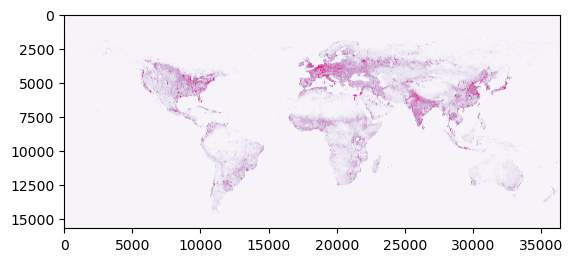

In [10]:
show(output_mask * output_tiff.read(1), cmap="PuRd", vmin=0, vmax=55)
plt.show()